In [9]:
import sys
sys.path.insert(0, '..')
from dependencies import *

envelopes_log = eelbrain.load.unpickle(PROCESSED_PREDICTOR_DIR / f'~processed_envelopes-log.pickle')
subject_model_predictors = eelbrain.load.unpickle(PREDICTOR_DIR / f'~concatenated_predictors.pickle')
durations = get_durations(envelopes_log)
models = get_models()


===== Subject S05 =====
Comparing TRFs for model: envelope_log
Comparing TRFs for model: envelope_onset

===== Subject S08 =====
Comparing TRFs for model: envelope_log
Comparing TRFs for model: envelope_onset

===== Subject S34 =====
Comparing TRFs for model: envelope_log
Comparing TRFs for model: envelope_onset


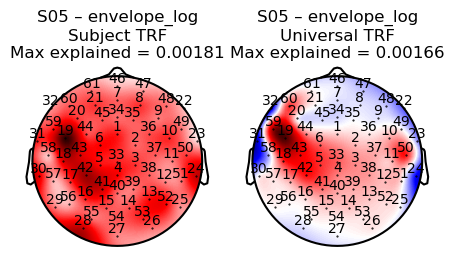

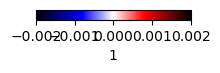

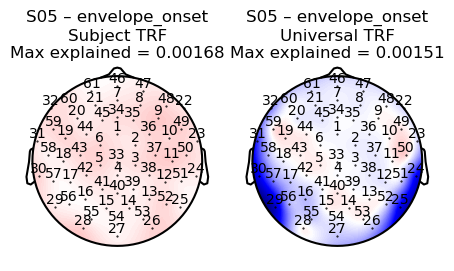

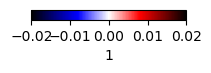

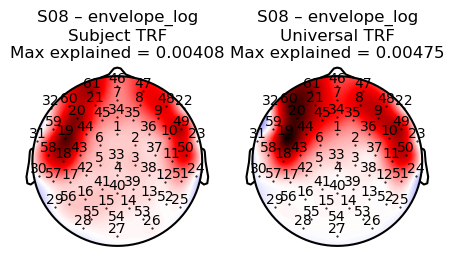

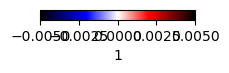

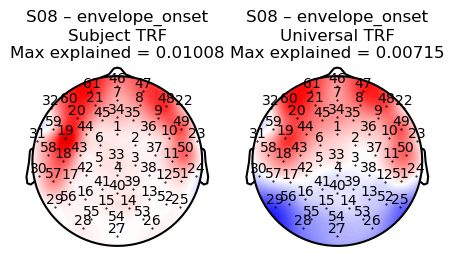

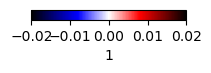

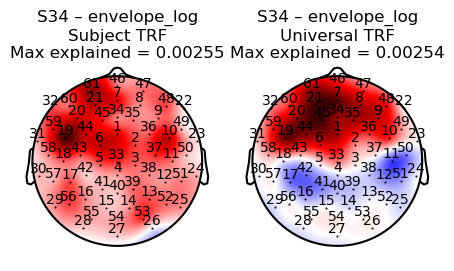

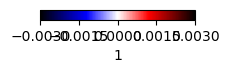

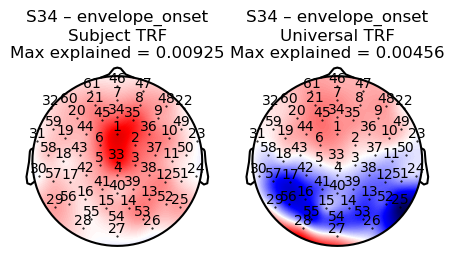

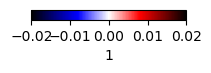

In [10]:
subjects = ['S05', 'S08', 'S34']
# Load universal TRFs for all models
universal_trfs = {model: eelbrain.load.unpickle(TRF_DIR / f'universal-trf-{model}.pickle') for model in models}

for subject in subjects:
    print(f'\n===== Subject {subject} =====')

    eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject}concatenated_eeg.pickle')

    for model in models:
        print(f'Comparing TRFs for model: {model}')

        # --- Subject TRF ---
        trf_subject = eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} {model}.pickle')
        predictor = subject_model_predictors[subject][model]
        eeg_predicted_subject = eelbrain.convolve(trf_subject.h_scaled, predictor)

        ss_total = ((eeg - eeg.mean('time')) ** 2).sum('time')
        ss_residual_subject = ((eeg - eeg_predicted_subject) ** 2).sum('time')
        proportion_explained_subject = 1 - (ss_residual_subject / ss_total)

        # --- Universal TRF ---
        trf_universal = universal_trfs[model]
        eeg_predicted_universal = eelbrain.convolve(trf_universal, predictor)
        ss_residual_universal = ((eeg - eeg_predicted_universal) ** 2).sum('time')
        proportion_explained_universal = 1 - (ss_residual_universal / ss_total)

        # --- Plot side-by-side ---
        titles = [
            f'{subject} – {model}\nSubject TRF\nMax explained = {proportion_explained_subject.max().round(5)}',
            f'{subject} – {model}\nUniversal TRF\nMax explained = {proportion_explained_universal.max().round(5)}'
        ]

        p = eelbrain.plot.Topomap(
            [proportion_explained_subject, proportion_explained_universal],
            sensorlabels='name',
            clip='circle',
            rows=1,
            axtitle=titles
        )
        p_cb = p.plot_colorbar(width=.1, w=2)

# Deprecated code


===== Subject S01 =====
Running model: envelope_log
<BoostingResult None ~ envelope_onset, -0.1 - 1, error=l1, basis=0.05, partitions=5, test=1, selective_stopping=1>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 73677 time>
<NDVar 'envelope_onset': 61 sensor, 73677 time>
Running model: envelope_onset
<BoostingResult None ~ envelope_log, -0.1 - 1, error=l1, basis=0.05, partitions=5, test=1, selective_stopping=1>
<NDVar 'envelope_log': 61 sensor, 114 time>
<NDVar 'envelope_log': 73677 time>
<NDVar 'envelope_log': 61 sensor, 73677 time>

===== Subject S03 =====
Running model: envelope_log
<BoostingResult None ~ envelope_onset, -0.1 - 1, error=l1, basis=0.05, partitions=5, test=1, selective_stopping=1>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 73677 time>
<NDVar 'envelope_onset': 61 sensor, 73677 time>
Running model: envelope_onset
<BoostingResult None ~ envelope_log, -0.1 - 1, error=l1, basis=0.05, partitions=5, test=1, selective_sto

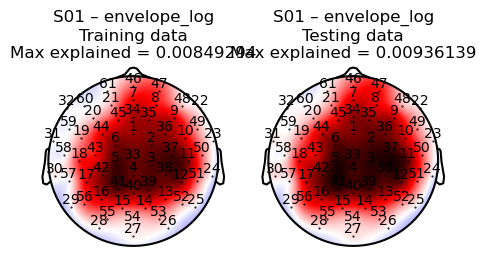

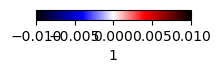

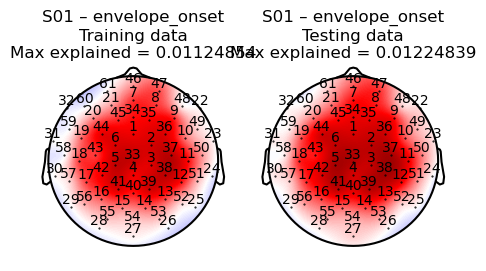

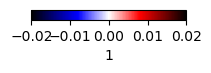

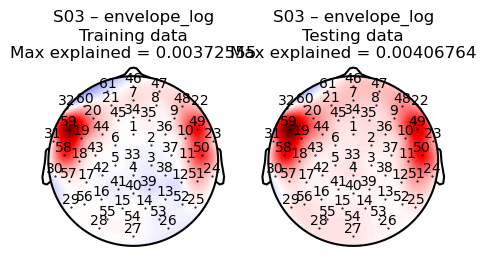

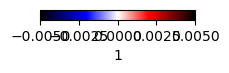

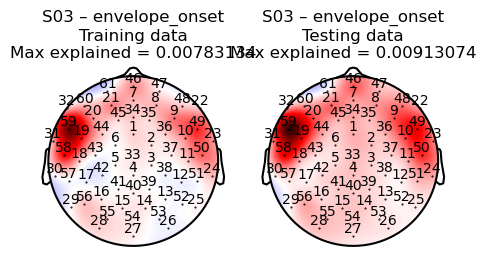

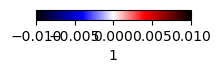

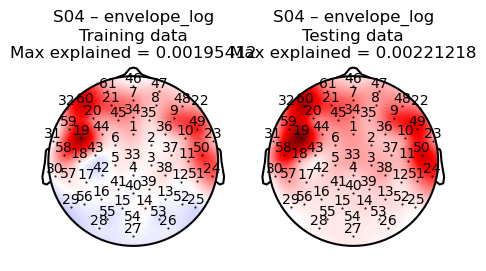

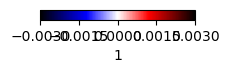

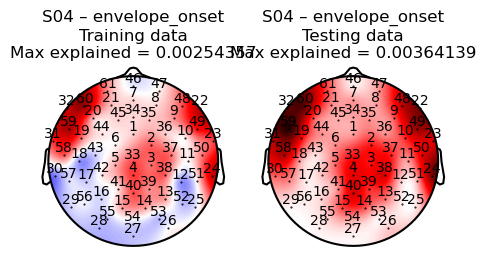

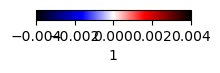

In [11]:
subjects = ['S01', 'S03', 'S04']
eeg_list = []
eeg_predicted_list = []

for subject in subjects:
    print(f'\n===== Subject {subject} =====')
    eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject}concatenated_eeg.pickle')
    eeg_list.append(eeg)

    for model in models:
        print(f'Running model: {model}')

        # Load decoder
        trf_encoder = eelbrain.load.unpickle(TRF_DIR / f'{subject}' / f'{subject} {model}.pickle')

        # True eeg
        predictor = subject_model_predictors[subject][model]
        print(trf_encoder)
        print(trf_encoder.h_scaled)
        print(predictor)

        # Predict EEG from predictors
        eeg_predicted = eelbrain.convolve(trf_encoder.h_scaled, predictor)
        eeg_predicted_list.append(eeg_predicted)
        print(eeg_predicted)

        # --- Evaluate prediction ---
        ss_total = eeg.abs().sum('time')
        ss_residual = (eeg - eeg_predicted).abs().sum('time')
        proportion_explained = 1 - (ss_residual / ss_total)

        # Plot results
        titles = [
            f'{subject} – {model}\nTraining data\nMax explained = {trf_encoder.proportion_explained.max().round(8)}',
            f'{subject} – {model}\nTesting data\nMax explained = {proportion_explained.max().round(8)}'
        ]

        p = eelbrain.plot.Topomap(
            [trf_encoder.proportion_explained, proportion_explained],
            sensorlabels='name',
            clip='circle',
            rows=1,
            axtitle=titles
        )

        p_cb = p.plot_colorbar(width=.1, w=2)

In [12]:
subject = 'S05'
model = 'envelope_log_8band'
trf_encoder = eelbrain.load.unpickle(TRF_DIR / f'{subject}' / f'{subject} {model}.pickle')
eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject}concatenated_eeg.pickle')
predictor = subject_model_predictors[subject][model]

print(trf_encoder)
print(trf_encoder.h_scaled)
print(predictor)

eeg_predicted = eelbrain.convolve(trf_encoder.h_scaled[0], predictor) # Right now is a tuple, re-run estimate TRFs to get new
print(eeg_predicted)

KeyError: 'envelope_log_8band'

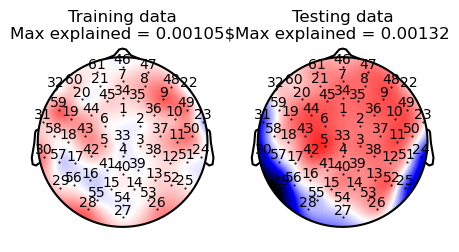

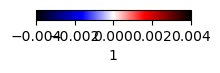

In [ ]:
# Evaluate cross-validated predictions
ss_total = eeg.abs().sum('time')
ss_residual = (eeg - eeg_predicted).abs().sum('time')
proportion_explained = 1 - (ss_residual / ss_total)
# Plot correlation on estimation and testing data
titles = [f'Training data\nMax explained = {trf_encoder.proportion_explained.max().round(5)}$', f'Testing data\nMax explained = {proportion_explained.max().round(5)}']
p = eelbrain.plot.Topomap([trf_encoder.proportion_explained, proportion_explained], sensorlabels='name', clip='circle', rows=1, axtitle=titles)
p_cb = p.plot_colorbar(width=.1, w=2)

# Predict using the universal TRF

In [ ]:
subject = 'S05'
model = 'envelope_log'
trf_encoder = eelbrain.load.unpickle(TRF_DIR / 'universal-trf-average.pickle')
eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject}concatenated_eeg.pickle')
predictor = subject_model_predictors[subject][model]

print(trf_encoder)
print(trf_encoder)
print(predictor)

eeg_predicted = eelbrain.convolve(trf_encoder, predictor) # Right now is a tuple, re-run estimate TRFs to get new
print(eeg_predicted)

<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 73677 time>
<NDVar 'envelope_onset': 61 sensor, 73677 time>


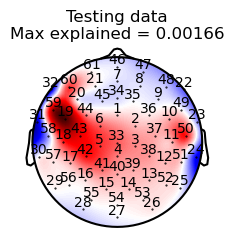

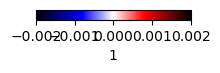

In [ ]:
# Evaluate cross-validated predictions
ss_total = ((eeg - eeg.mean('time')) ** 2).sum('time')
ss_residual = ((eeg - eeg_predicted) ** 2).sum('time')
proportion_explained = 1 - (ss_residual / ss_total)

# Plot topography of explained variance
title = f'Testing data\nMax explained = {proportion_explained.max().round(5)}'
p = eelbrain.plot.Topomap(proportion_explained, sensorlabels='name', clip='circle', axtitle=title)
p_cb = p.plot_colorbar(width=.1, w=2)